In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import joblib
import matplotlib.pyplot as plt

In [5]:
X_train = np.load("X_train_multi.npy")  # Shape: (176485, 24, 1)
y_train = np.load("y_train_multi.npy")  # Shape: (176485, 4)
X_val   = np.load("X_val_multi.npy")    # Shape: (37594, 24, 1)
y_val   = np.load("y_val_multi.npy")    # Shape: (37594, 4)
X_test  = np.load("X_test_multi.npy")   # Shape: (37221, 24, 1)
y_test  = np.load("y_test_multi.npy")   # Shape: (37221, 4)

scaler = joblib.load("scaler_multi.pkl")  # Multi-patient scaler

In [6]:


print("MULTI-PATIENT DATASET SHAPES:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print(f"\nLookback: {X_train.shape[1]} timesteps, Horizon: {y_train.shape[1]} steps")

# ==================== 2. SHUFFLE TRAINING DATA ====================
print("\nShuffling training data...")
indices = np.random.permutation(len(X_train))
X_train = X_train[indices]
y_train = y_train[indices]

MULTI-PATIENT DATASET SHAPES:
X_train: (176485, 24, 1) y_train: (176485, 4)
X_val  : (37594, 24, 1) y_val  : (37594, 4)
X_test : (37221, 24, 1) y_test : (37221, 4)

Lookback: 24 timesteps, Horizon: 4 steps

Shuffling training data...


In [7]:
print("Dataset Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Dataset Shapes:
X_train: (176485, 24, 1) y_train: (176485, 4)
X_val  : (37594, 24, 1) y_val  : (37594, 4)
X_test : (37221, 24, 1) y_test : (37221, 4)


In [8]:
# Build RNN model
model = Sequential()

# SimpleRNN layer (Vanilla RNN) - NOTE: uses tanh activation by default
model.add(SimpleRNN(
    units=128,  # Need more units for RNN (less expressive per unit)
    input_shape=(X_train.shape[1], X_train.shape[2]),
    return_sequences=False,  # Single RNN layer
    activation='tanh',  # Vanilla RNN uses tanh
    name='simple_rnn_layer'
))

# Dropout - RNN needs more regularization (prone to overfitting)
model.add(Dropout(0.3))  # Higher dropout than LSTM/GRU

# Additional dense layer (RNN benefits from feature transformation)
model.add(Dense(
    units=32,
    activation='relu',
    name='dense_feature'
))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(
    units=y_train.shape[1],  # 4 steps
    activation='linear',
    name='output'
))

# Compile with slightly higher learning rate (RNN needs it)
model.compile(
    optimizer=Adam(learning_rate=0.002),  # Higher LR than LSTM/GRU
    loss='mse',
    metrics=['mae', 'mse']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_layer (SimpleRNN)    │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature (Dense)           │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,900 (81.64 KB)

 Trainable params: 20,900 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Callbacks with more patience (RNN Slower)
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=20,  # More patience for RNN
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_rnn_glucose_model.h5',
    monitor='val_mae',
    save_best_only=True,
    verbose=1
)

In [10]:
# Train model
print("\nTraining SimpleRNN for glucose prediction...")
print("Note: RNN may train slower and need more epochs")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,  # More epochs for RNN
    batch_size=32,  # Smaller batch size for RNN stability
    callbacks=[early_stop, checkpoint],
    verbose=1,
    shuffle=True
)


Training SimpleRNN for glucose prediction...
Note: RNN may train slower and need more epochs
Epoch 1/150
5509/5516 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 - mae: 0.0519 - mse: 0.0057
Epoch 1: val_mae improved from inf to 0.03871, saving model to best_rnn_glucose_model.h5


5516/5516 ━━━━━━━━━━━━━━━━━━━━ 49s 8ms/step - loss: 0.0057 - mae: 0.0518 - mse: 0.0057 - val_loss: 0.0033 - val_mae: 0.0387 - val_mse: 0.0033
Epoch 2/150
5514/5516 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0337 - mae: 0.0896 - mse: 0.0337
Epoch 2: val_mae did not improve from 0.03871
5516/5516 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 0.0337 - mae: 0.0896 - mse: 0.0337 - val_loss: 0.0194 - val_mae: 0.1106 - val_mse: 0.0194
Epoch 3/150
5512/5516 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0168 - mae: 0.1018 - mse: 0.0168
Epoch 3: val_mae did not improve from 0.03871
5516/5516 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - loss: 0.0168 - mae: 0.1018 - mse: 0.0168 - val_loss: 0.0205 - val_mae: 0.1152 - val_mse: 0.0205
Epoch 4/150
5511/5516 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0189 - mae: 0.1104 - mse: 0.0189
Epoch 4: val_mae did not improve from 0.03871
5516/5516 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 0.0189 - mae: 0.1104 - mse: 0.0189 - val_loss: 0.0205 - val_mae: 0.1153 - val_mse: 0.0205


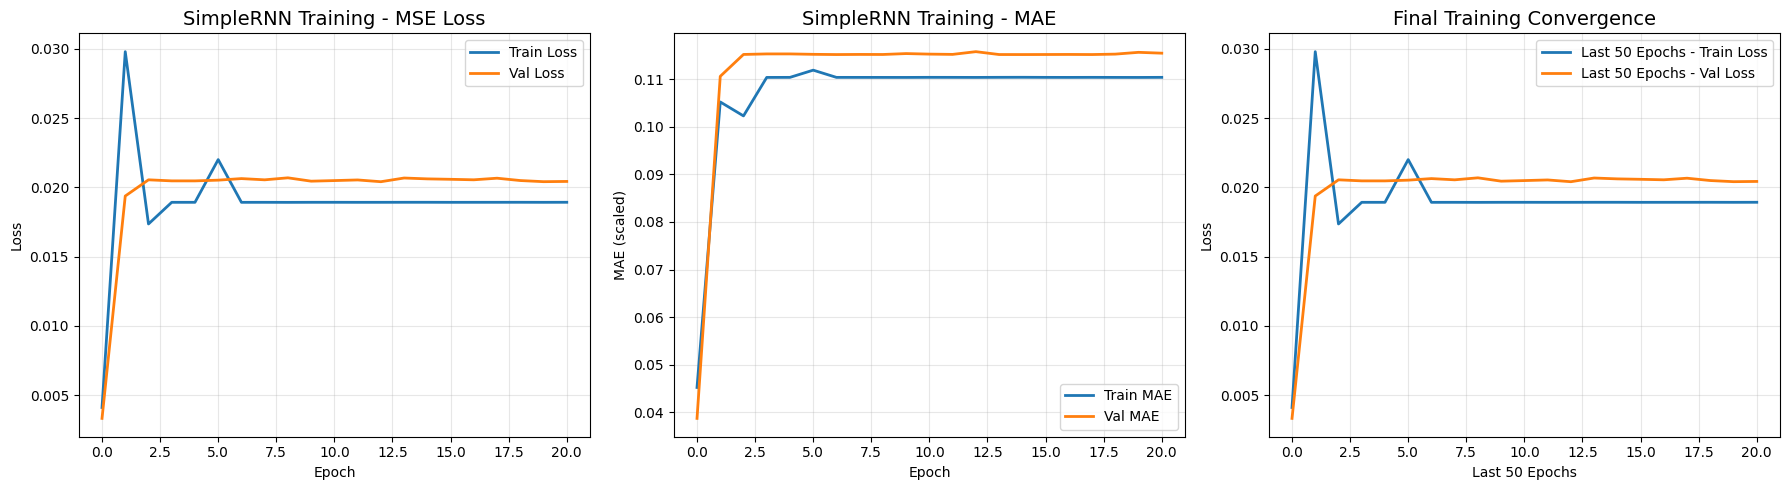

In [11]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_title('SimpleRNN Training - MSE Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_title('SimpleRNN Training - MAE', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate (if tracked)
if 'lr' in history.history:
    axes[2].plot(history.history['lr'], label='Learning Rate', linewidth=2, color='purple')
    axes[2].set_title('Learning Rate Schedule', fontsize=14)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    # Show loss convergence instead
    axes[2].plot(history.history['loss'][-50:], label='Last 50 Epochs - Train Loss', linewidth=2)
    axes[2].plot(history.history['val_loss'][-50:], label='Last 50 Epochs - Val Loss', linewidth=2)
    axes[2].set_title('Final Training Convergence', fontsize=14)
    axes[2].set_xlabel('Last 50 Epochs')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Predict on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse transform function
def inverse_transform_sequence(y_scaled, scaler):
    y_scaled_flat = y_scaled.flatten().reshape(-1, 1)
    y_real = scaler.inverse_transform(y_scaled_flat)
    return y_real.reshape(y_scaled.shape)

# Inverse transform
y_pred = inverse_transform_sequence(y_pred_scaled, scaler)
y_real = inverse_transform_sequence(y_test, scaler)

In [13]:
# Calculate metrics for each prediction step
n_steps = y_real.shape[1]

print("\n" + "="*60)
print("SIMPLE RNN PREDICTION RESULTS - PATIENT LIB193263")
print("="*60)
print(f"Model: SimpleRNN (128 units) + Dense(32)")
print(f"Lookback: 48 timesteps, Horizon: {n_steps} steps")

metrics_by_horizon = []

for step in range(n_steps):
    time_minutes = 15 * (step + 1)

    rmse_step = np.sqrt(np.mean((y_real[:, step] - y_pred[:, step])**2))
    mae_step = np.mean(np.abs(y_real[:, step] - y_pred[:, step]))
    mape_step = np.mean(np.abs((y_real[:, step] - y_pred[:, step]) / (y_real[:, step] + 1e-8))) * 100
    accuracy_step = 100 - mape_step

    metrics_by_horizon.append({
        'time': time_minutes,
        'rmse': rmse_step,
        'mae': mae_step,
        'mape': mape_step,
        'accuracy': accuracy_step
    })

    print(f"\n{time_minutes}-min ahead prediction:")
    print(f"  RMSE : {rmse_step:.2f} mg/dL")
    print(f"  MAE  : {mae_step:.2f} mg/dL")
    print(f"  MAPE : {mape_step:.2f}%")
    print(f"  Accuracy: {accuracy_step:.2f}%")


SIMPLE RNN PREDICTION RESULTS - PATIENT LIB193263
Model: SimpleRNN (128 units) + Dense(32)
Lookback: 48 timesteps, Horizon: 4 steps

15-min ahead prediction:
  RMSE : 12.83 mg/dL
  MAE  : 8.13 mg/dL
  MAPE : 5.51%
  Accuracy: 94.49%

30-min ahead prediction:
  RMSE : 20.56 mg/dL
  MAE  : 14.33 mg/dL
  MAPE : 9.79%
  Accuracy: 90.21%

45-min ahead prediction:
  RMSE : 29.36 mg/dL
  MAE  : 21.00 mg/dL
  MAPE : 14.92%
  Accuracy: 85.08%

60-min ahead prediction:
  RMSE : 35.20 mg/dL
  MAE  : 25.74 mg/dL
  MAPE : 18.49%
  Accuracy: 81.51%


In [14]:
# Calculate overall metrics
overall_rmse = np.sqrt(np.mean((y_real - y_pred)**2))
overall_mae = np.mean(np.abs(y_real - y_pred))
overall_mape = np.mean(np.abs((y_real - y_pred) / (y_real + 1e-8))) * 100

print("\n" + "="*60)
print("OVERALL PERFORMANCE (all horizons):")
print("="*60)
print(f"Overall RMSE: {overall_rmse:.2f} mg/dL")
print(f"Overall MAE : {overall_mae:.2f} mg/dL")
print(f"Overall MAPE: {overall_mape:.2f}%")


OVERALL PERFORMANCE (all horizons):
Overall RMSE: 25.93 mg/dL
Overall MAE : 17.30 mg/dL
Overall MAPE: 12.18%


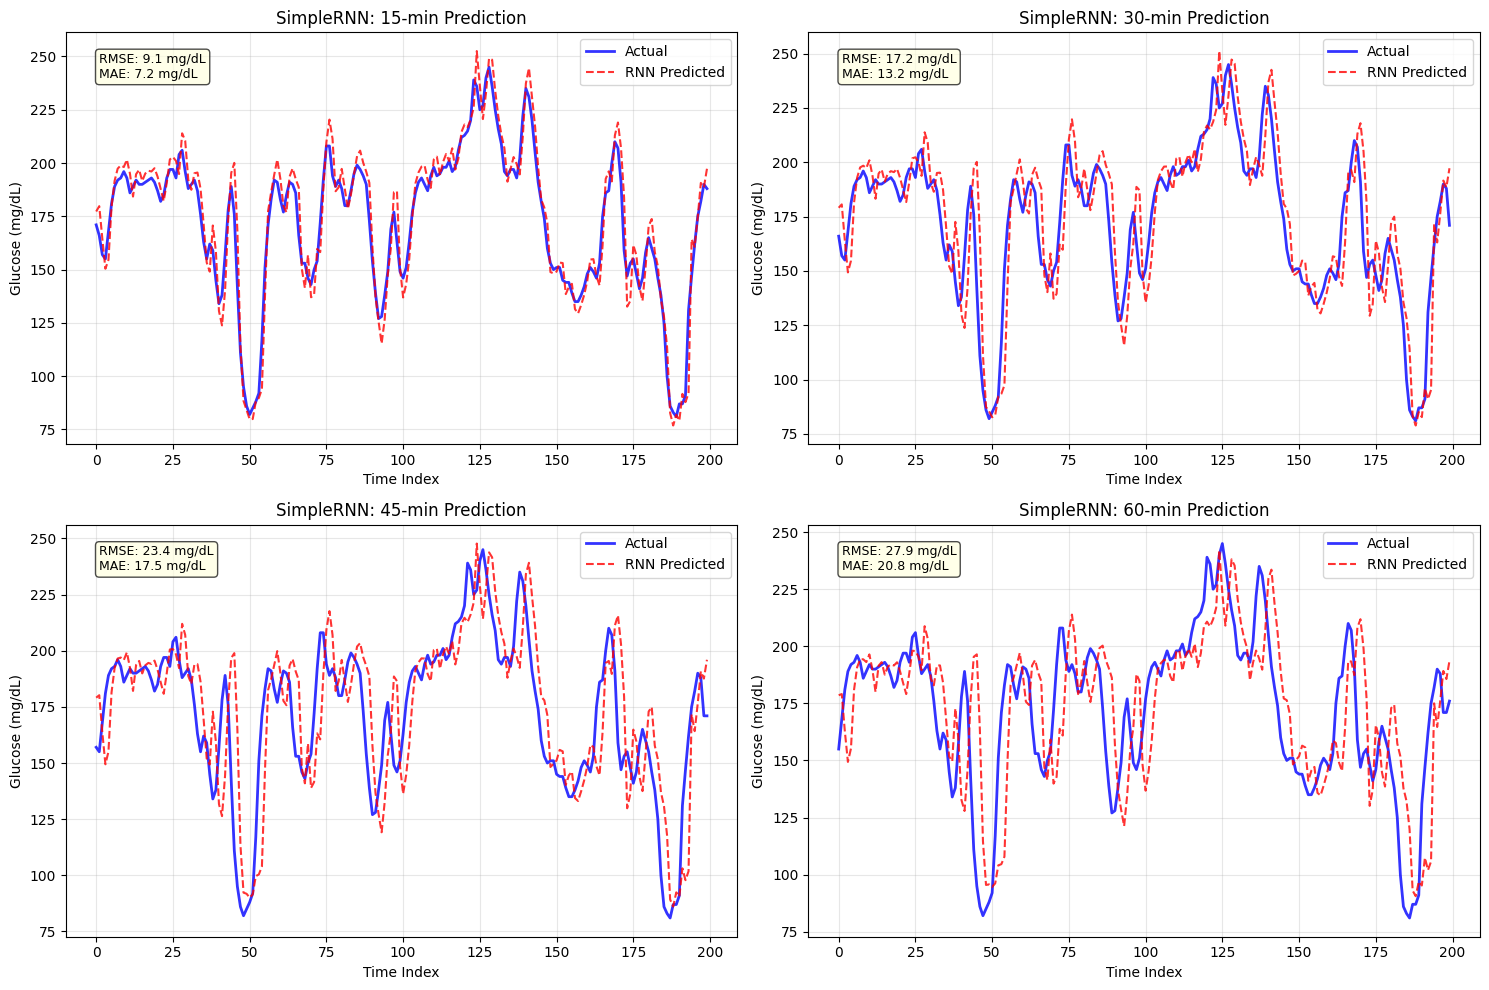

In [15]:
# Plot predictions
n_plot = 200  # Show first 200 predictions

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

prediction_horizons = ['15-min', '30-min', '45-min', '60-min']

for step in range(n_steps):
    ax = axes[step]
    ax.plot(y_real[:n_plot, step], label='Actual', linewidth=2, alpha=0.8, color='blue')
    ax.plot(y_pred[:n_plot, step], label='RNN Predicted', linewidth=1.5, linestyle='--', alpha=0.8, color='red')
    ax.set_title(f'SimpleRNN: {prediction_horizons[step]} Prediction', fontsize=12)
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Glucose (mg/dL)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add metrics in text box
    rmse = np.sqrt(np.mean((y_real[:n_plot, step] - y_pred[:n_plot, step])**2))
    mae = np.mean(np.abs(y_real[:n_plot, step] - y_pred[:n_plot, step]))
    ax.text(0.05, 0.95, f'RMSE: {rmse:.1f} mg/dL\nMAE: {mae:.1f} mg/dL',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('rnn_predictions_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

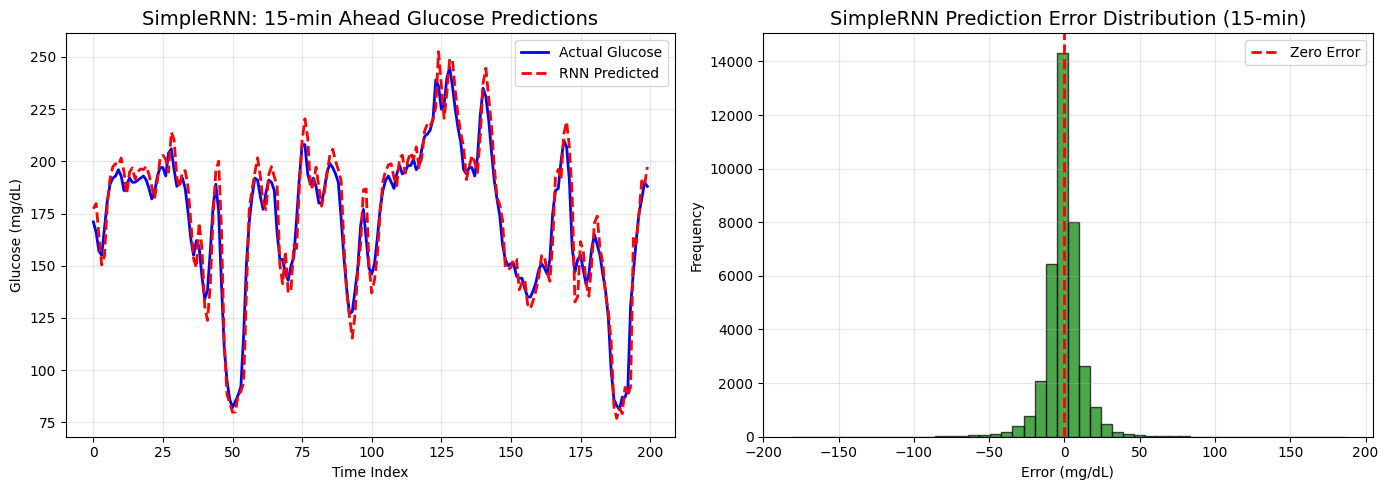

In [16]:
# Create a combined plot for 15-min predictions only (most important)
plt.figure(figsize=(14, 5))

# Plot 1: Time series
plt.subplot(1, 2, 1)
plt.plot(y_real[:n_plot, 0], label='Actual Glucose', linewidth=2, color='blue')
plt.plot(y_pred[:n_plot, 0], label='RNN Predicted', linewidth=2, linestyle='--', color='red')
plt.title('SimpleRNN: 15-min Ahead Glucose Predictions', fontsize=14)
plt.xlabel('Time Index')
plt.ylabel('Glucose (mg/dL)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Error histogram
plt.subplot(1, 2, 2)
errors = y_real[:, 0] - y_pred[:, 0]
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.title('SimpleRNN Prediction Error Distribution (15-min)', fontsize=14)
plt.xlabel('Error (mg/dL)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_15min_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# Save predictions
np.save('rnn_predictions.npy', y_pred)
np.save('rnn_actuals.npy', y_real)